# Notebook 03 — Modelos de Series Temporales: SARIMA y Prophet
**TFM · Predicción de Ventas para Optimización de Stock**  
Familias: PVC · PE · PE-X (reticulado)

**Objetivos:**
1. Selección automática de órdenes SARIMA mediante `auto_arima` (criterio AIC)
2. Ajuste y diagnóstico de residuos (Ljung-Box, ACF/PACF, QQ-plot)
3. Modelo Prophet con estacionalidad múltiple y detección de changepoints
4. Validación walk-forward sin fuga de datos (12 meses de test)
5. Comparativa de métricas: RMSE · MAE · MAPE · SMAPE
6. Exportación de predicciones y figuras para LaTeX

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.statespace.sarimax  import SARIMAX
from statsmodels.graphics.tsaplots       import plot_acf, plot_pacf
from statsmodels.stats.diagnostic        import acorr_ljungbox
from scipy                               import stats
import pmdarima as pm
from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

FAMILIAS = None
COLORES  = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
H        = 12
ALPHA    = 0.05

print('Imports OK')

Importing plotly failed. Interactive plots will not work.


Imports OK


## 1. Carga y preparación de datos

In [3]:
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['PESO_BRUTO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
    .fillna(0)
)

FAMILIAS   = ventas_mensual.columns.tolist()
fechas_dt  = ventas_mensual.index.to_timestamp()

print(f'Periodo: {ventas_mensual.index[0]} -> {ventas_mensual.index[-1]}')
print(f'Total meses: {len(ventas_mensual)}')
print(f'Familias: {FAMILIAS}')
ventas_mensual.describe().round(0)

Periodo: 2010-12 -> 2026-02
Total meses: 163
Familias: [106, 124, 233]


FAMILIA,106,124,233
count,163.0,163.0,163.0
mean,5631.0,20449.0,42324.0
std,12854.0,25120.0,33583.0
min,0.0,0.0,0.0
25%,0.0,0.0,14884.0
50%,0.0,11172.0,35782.0
75%,4806.0,36055.0,60029.0
max,71347.0,107886.0,139563.0


In [4]:
def smape(actual, forecast):
    return 100 * np.mean(
        2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + 1e-9)
    )

def calcular_metricas(actual, forecast, nombre_modelo, familia):
    return {
        'Modelo'   : nombre_modelo,
        'Familia'  : familia,
        'RMSE'     : round(np.sqrt(mean_squared_error(actual, forecast)), 2),
        'MAE'      : round(mean_absolute_error(actual, forecast), 2),
        'MAPE_%'   : round(mean_absolute_percentage_error(actual, forecast) * 100, 2),
        'SMAPE_%'  : round(smape(actual, forecast), 2),
    }

print('Funciones auxiliares OK')

Funciones auxiliares OK


## 2. Modelo SARIMA

### 2.1 Selección automática de órdenes con `auto_arima`

Búsqueda escalonada sobre la rejilla:
- p, q en {0,1,2,3}
- d = 1 (confirmado por ADF en Notebook 02)
- P, Q en {0,1,2}, D = 1, s = 12

Criterio de selección: **AIC**.

In [5]:
from scipy.stats.mstats import winsorize

# Winsorización: solo afecta al entrenamiento
ventas_mensual_wins = ventas_mensual.copy()
for fam in FAMILIAS:
    ventas_mensual_wins[fam] = winsorize(ventas_mensual[fam], limits=[0, 0.05])

USAR_LOG = {fam: False for fam in FAMILIAS}

# ── auto_arima ────────────────────────────────────────────────────────────────
ordenes_sarima = {}

for familia in FAMILIAS:
    print(f'\n{"="*50}')
    print(f'  auto_arima -> Familia {familia}')
    print(f'{"="*50}')

    serie_train = ventas_mensual_wins[familia].values[:-H]  # ← wins aquí
    if USAR_LOG[familia]:
        serie_train = np.log1p(serie_train)                 # ← log encima de wins

    auto = pm.auto_arima(
        serie_train,
        start_p=0, max_p=3, start_q=0, max_q=3,
        d=None, D=1, m=12, seasonal=True,
        start_P=0, max_P=2, start_Q=0, max_Q=2,
        information_criterion='aic', stepwise=True,
        suppress_warnings=True, error_action='ignore', n_fits=30
    )

    ordenes_sarima[familia] = {
        'order'         : auto.order,
        'seasonal_order': auto.seasonal_order,
        'aic'           : round(auto.aic(), 2),
        'bic'           : round(auto.bic(), 2),
    }
    print(f'  Orden: SARIMA{auto.order} x {auto.seasonal_order}')
    print(f'  AIC = {auto.aic():.2f}  |  BIC = {auto.bic():.2f}')

print('\nauto_arima completado.')
pd.DataFrame(ordenes_sarima).T


  auto_arima -> Familia 106
  Orden: SARIMA(1, 0, 1) x (2, 1, 1, 12)
  AIC = 2883.16  |  BIC = 2903.70

  auto_arima -> Familia 124
  Orden: SARIMA(1, 0, 0) x (0, 1, 2, 12)
  AIC = 3076.01  |  BIC = 3090.68

  auto_arima -> Familia 233
  Orden: SARIMA(2, 0, 1) x (0, 1, 1, 12)
  AIC = 3255.22  |  BIC = 3269.89

auto_arima completado.


,order,seasonal_order,aic,bic
106,"(1, 0, 1)","(2, 1, 1, 12)",2883.16,2903.7
124,"(1, 0, 0)","(0, 1, 2, 12)",3076.01,3090.68
233,"(2, 0, 1)","(0, 1, 1, 12)",3255.22,3269.89


### 2.2 Ajuste y diagnóstico de residuos

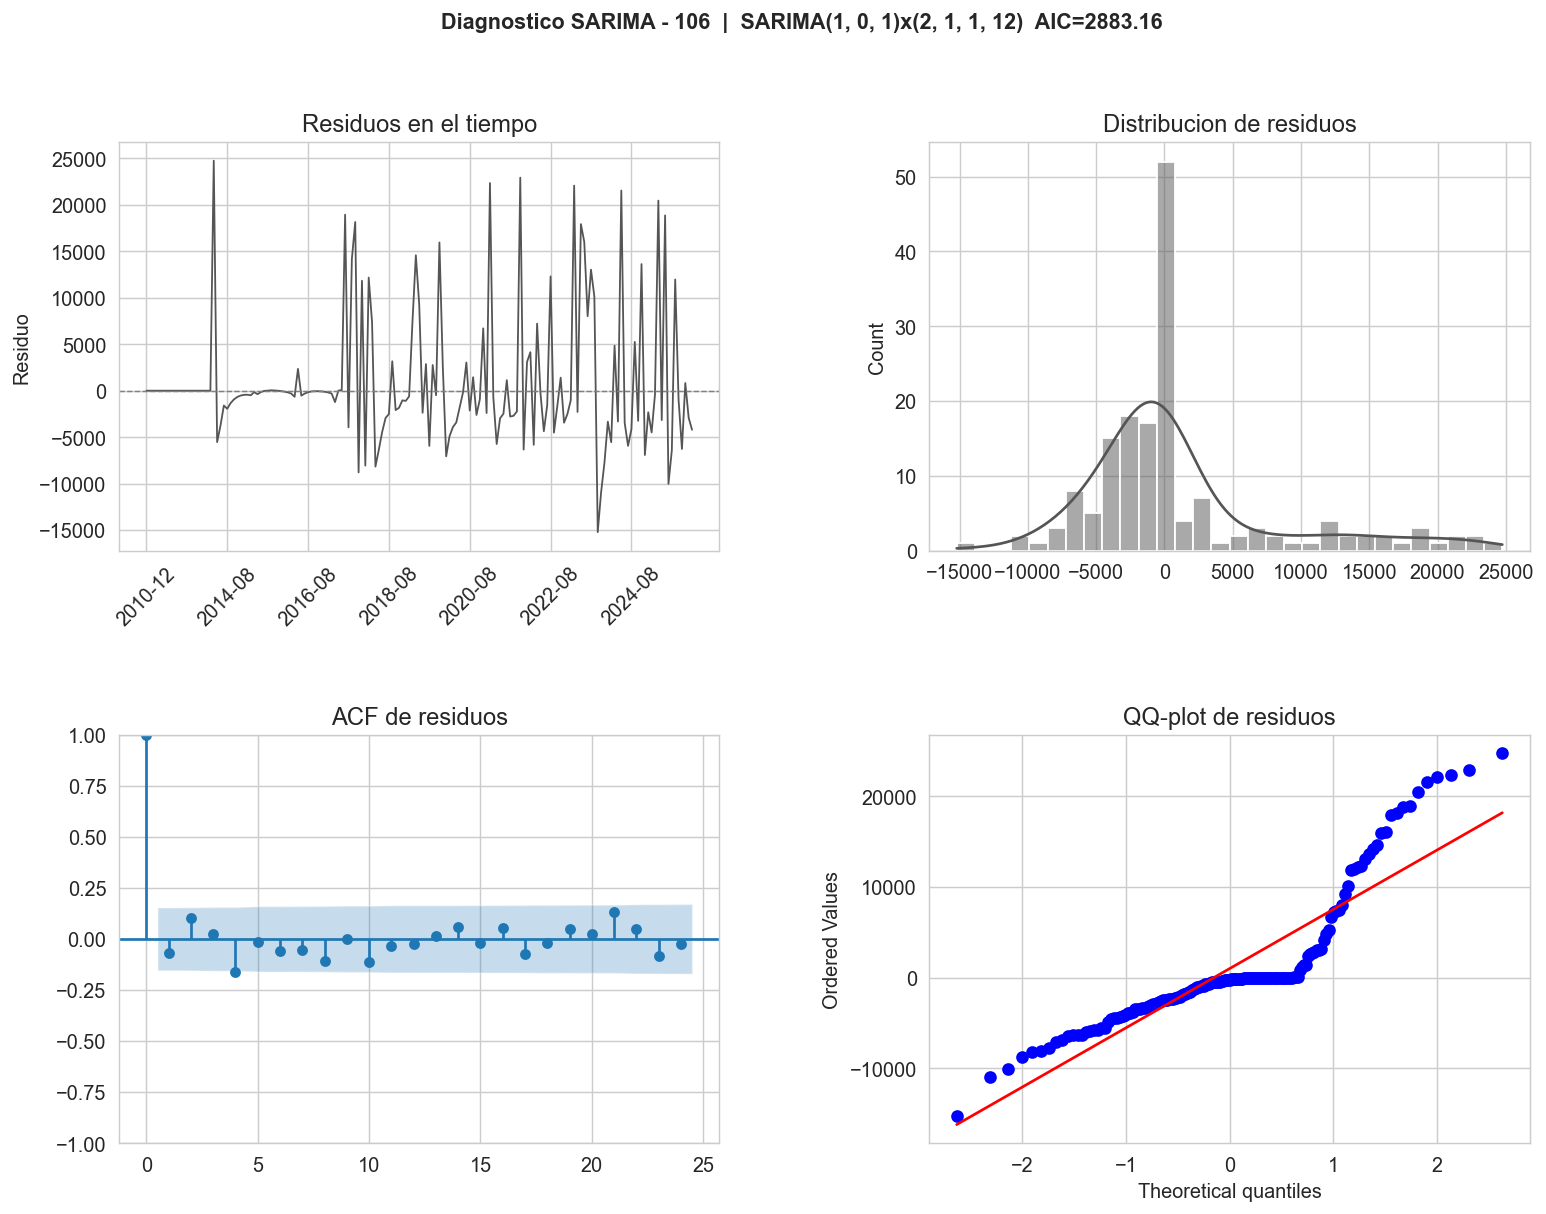

Figura guardada: ../figuras/04_diagnostico_SARIMA_106.pdf
Ljung-Box [106]:
      lb_stat  lb_pvalue
12  12.630919   0.396428
24  20.752765   0.653264
  -> Residuos no autocorrelacionados (ruido blanco)



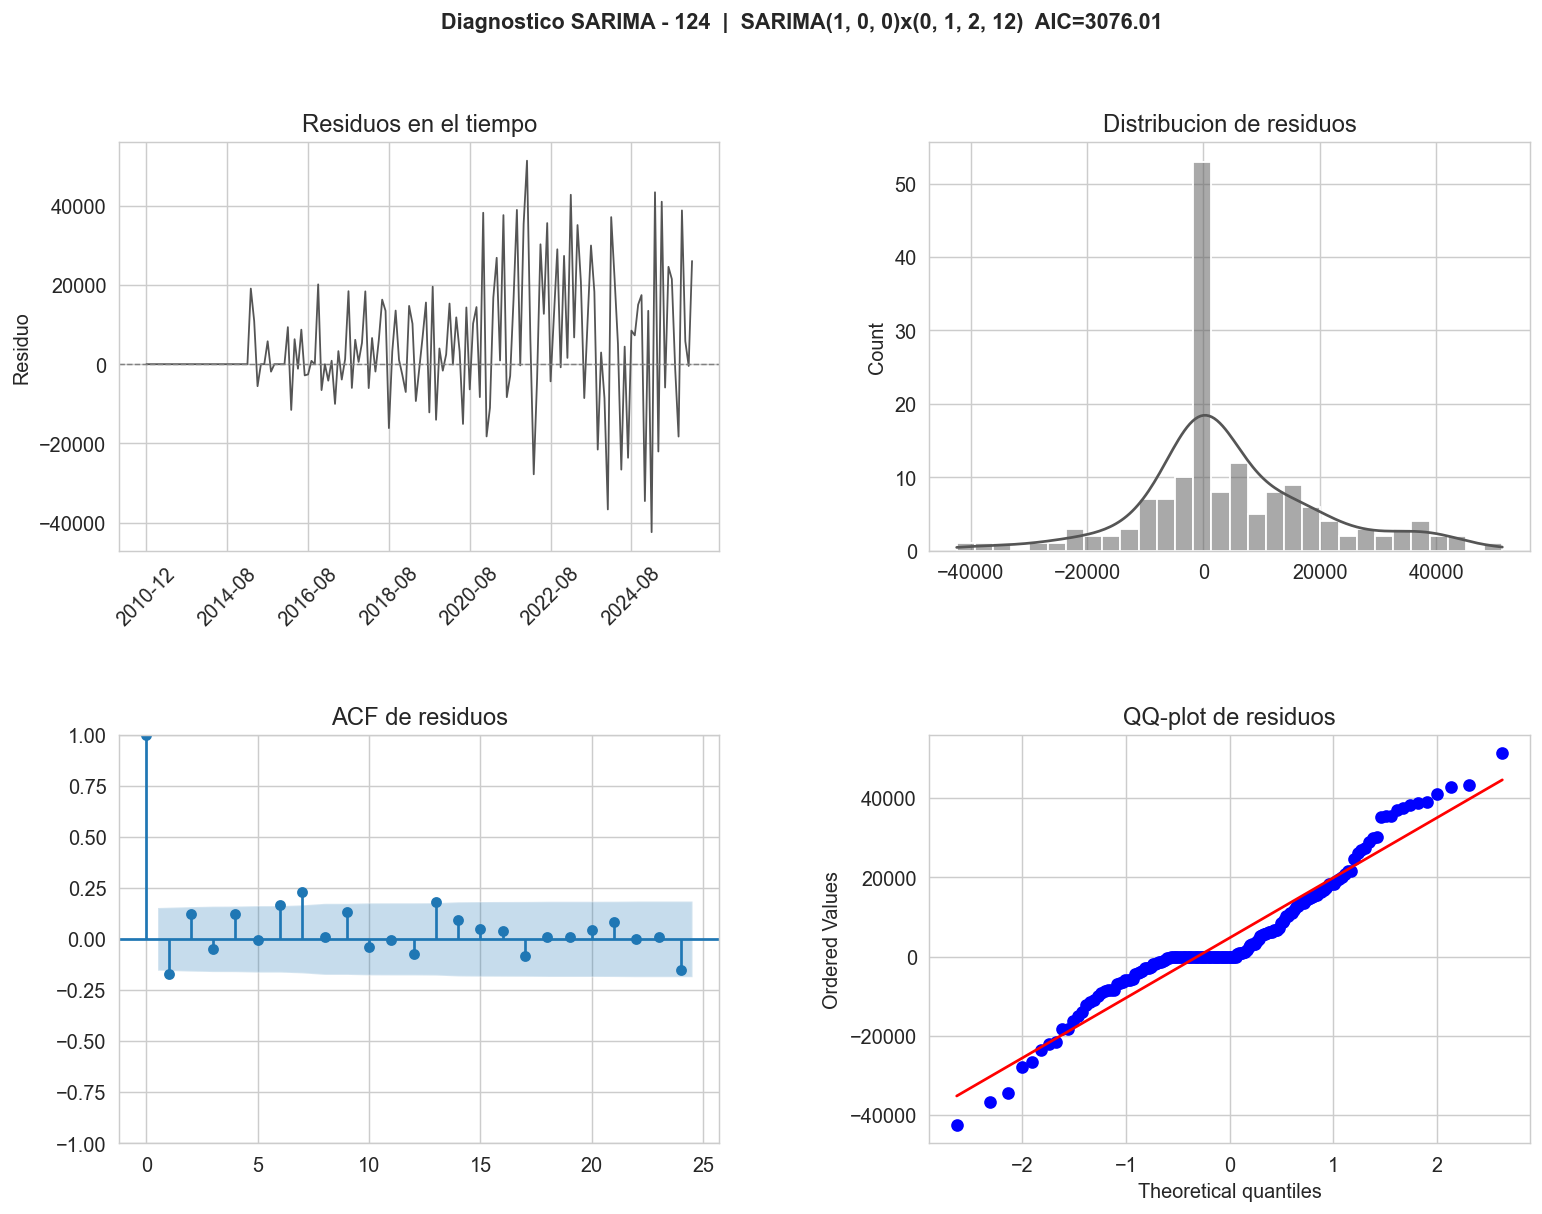

Figura guardada: ../figuras/04_diagnostico_SARIMA_124.pdf
Ljung-Box [124]:
      lb_stat  lb_pvalue
12  28.596578   0.004521
24  44.206229   0.007220
  -> Autocorrelacion remanente: considerar orden mayor



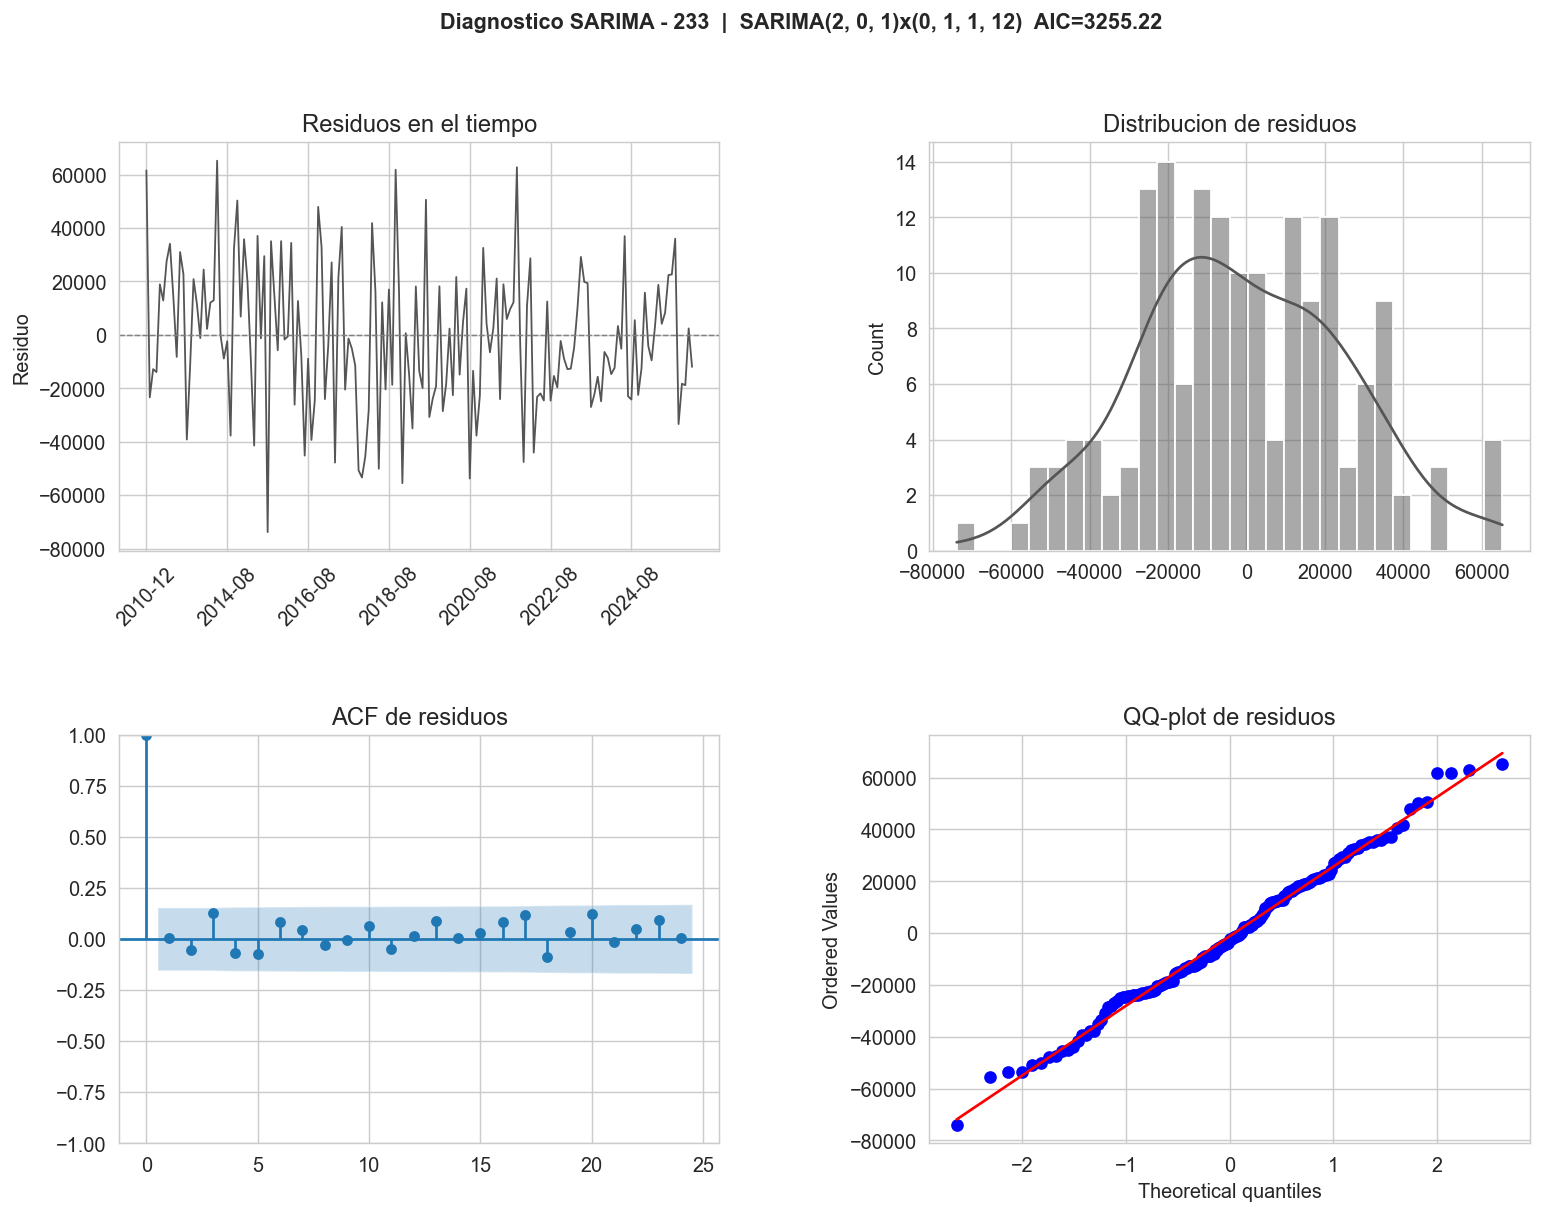

Figura guardada: ../figuras/04_diagnostico_SARIMA_233.pdf
Ljung-Box [233]:
      lb_stat  lb_pvalue
12   7.633325   0.813089
24  19.474957   0.726208
  -> Residuos no autocorrelacionados (ruido blanco)



In [6]:
# ── Diagnóstico sobre serie completa ─────────────────────────────────────────
modelos_sarima = {}

for familia in FAMILIAS:
    serie_full = ventas_mensual_wins[familia].values  # ← wins
    if USAR_LOG[familia]:
        serie_full_fit = np.log1p(serie_full)
    else:
        serie_full_fit = serie_full

    ords  = ordenes_sarima[familia]
    model = SARIMAX(serie_full_fit, order=ords['order'],
                    seasonal_order=ords['seasonal_order'],
                    enforce_stationarity=False, enforce_invertibility=False)
    res   = model.fit(disp=False)
    modelos_sarima[familia] = res

    residuos = res.resid
    color    = COLORES.get(familia, '#555')
    idx_str  = ventas_mensual.index.astype(str)

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(idx_str, residuos, color=color, lw=1.0)
    ax0.axhline(0, color='grey', lw=0.8, ls='--')
    ticks = range(0, len(idx_str), 24)
    ax0.set_xticks([idx_str[i] for i in ticks])
    ax0.tick_params(axis='x', rotation=45)
    ax0.set_title('Residuos en el tiempo')
    ax0.set_ylabel('Residuo')

    ax1 = fig.add_subplot(gs[0, 1])
    sns.histplot(residuos, kde=True, ax=ax1, color=color, bins=30)
    ax1.set_title('Distribucion de residuos')

    ax2 = fig.add_subplot(gs[1, 0])
    plot_acf(residuos, lags=24, ax=ax2, alpha=ALPHA)
    ax2.set_title('ACF de residuos')

    ax3 = fig.add_subplot(gs[1, 1])
    stats.probplot(residuos, dist='norm', plot=ax3)
    ax3.set_title('QQ-plot de residuos')

    fig.suptitle(
        f'Diagnostico SARIMA - {familia}  |  '
        f'SARIMA{ords["order"]}x{ords["seasonal_order"]}  AIC={ords["aic"]}',
        fontsize=12, fontweight='bold'
    )
    fname = f'../figuras/04_diagnostico_SARIMA_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

    lb = acorr_ljungbox(residuos, lags=[12, 24], return_df=True)
    print(f'Ljung-Box [{familia}]:')
    print(lb.to_string())
    if (lb['lb_pvalue'] > ALPHA).all():
        print('  -> Residuos no autocorrelacionados (ruido blanco)')
    else:
        print('  -> Autocorrelacion remanente: considerar orden mayor')
    print()

### 2.3 Validacion walk-forward

Entrenamos con los primeros T-H meses y predecimos los ultimos H=12 meses.
Evita data leakage al no usar datos futuros en el entrenamiento.

In [7]:
# ── Walk-forward ──────────────────────────────────────────────────────────────
resultados_sarima   = []
predicciones_sarima = {}

for familia in FAMILIAS:
    serie_full = ventas_mensual[familia].values          # original para métricas
    test_vals  = serie_full[-H:]

    train_wins = ventas_mensual_wins[familia].values[:-H]
    if USAR_LOG[familia]:
        train_wins = np.log1p(train_wins)

    ords     = ordenes_sarima[familia]
    model_wf = SARIMAX(train_wins, order=ords['order'],
                       seasonal_order=ords['seasonal_order'],
                       enforce_stationarity=False, enforce_invertibility=False)
    res_wf   = model_wf.fit(disp=False)
    fc_obj   = res_wf.get_forecast(steps=H)
    fc_ci    = fc_obj.conf_int(alpha=ALPHA)

    if USAR_LOG[familia]:
        fc_mean  = np.clip(np.expm1(fc_obj.predicted_mean), 0, None)
        fc_lower = np.clip(np.expm1(fc_ci[:, 0]),           0, None)
        fc_upper = np.expm1(fc_ci[:, 1])
    else:
        fc_mean  = np.clip(fc_obj.predicted_mean, 0, None)
        fc_lower = np.clip(fc_ci[:, 0],           0, None)
        fc_upper = fc_ci[:, 1]

    metricas = calcular_metricas(test_vals, fc_mean, 'SARIMA', familia)
    resultados_sarima.append(metricas)
    predicciones_sarima[familia] = {
        'test'    : test_vals,
        'fc_mean' : fc_mean,
        'fc_lower': fc_lower,
        'fc_upper': fc_upper,
    }
    print(f'[{familia}]  RMSE={metricas["RMSE"]:>10.2f}  '
          f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
          f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nWalk-forward SARIMA completado.')

[106]  RMSE=  28588.10  MAPE=153.09%  SMAPE=107.29%
[124]  RMSE=  41125.91  MAPE= 45.83%  SMAPE= 64.93%
[233]  RMSE=  20523.34  MAPE= 57.16%  SMAPE= 59.86%

Walk-forward SARIMA completado.


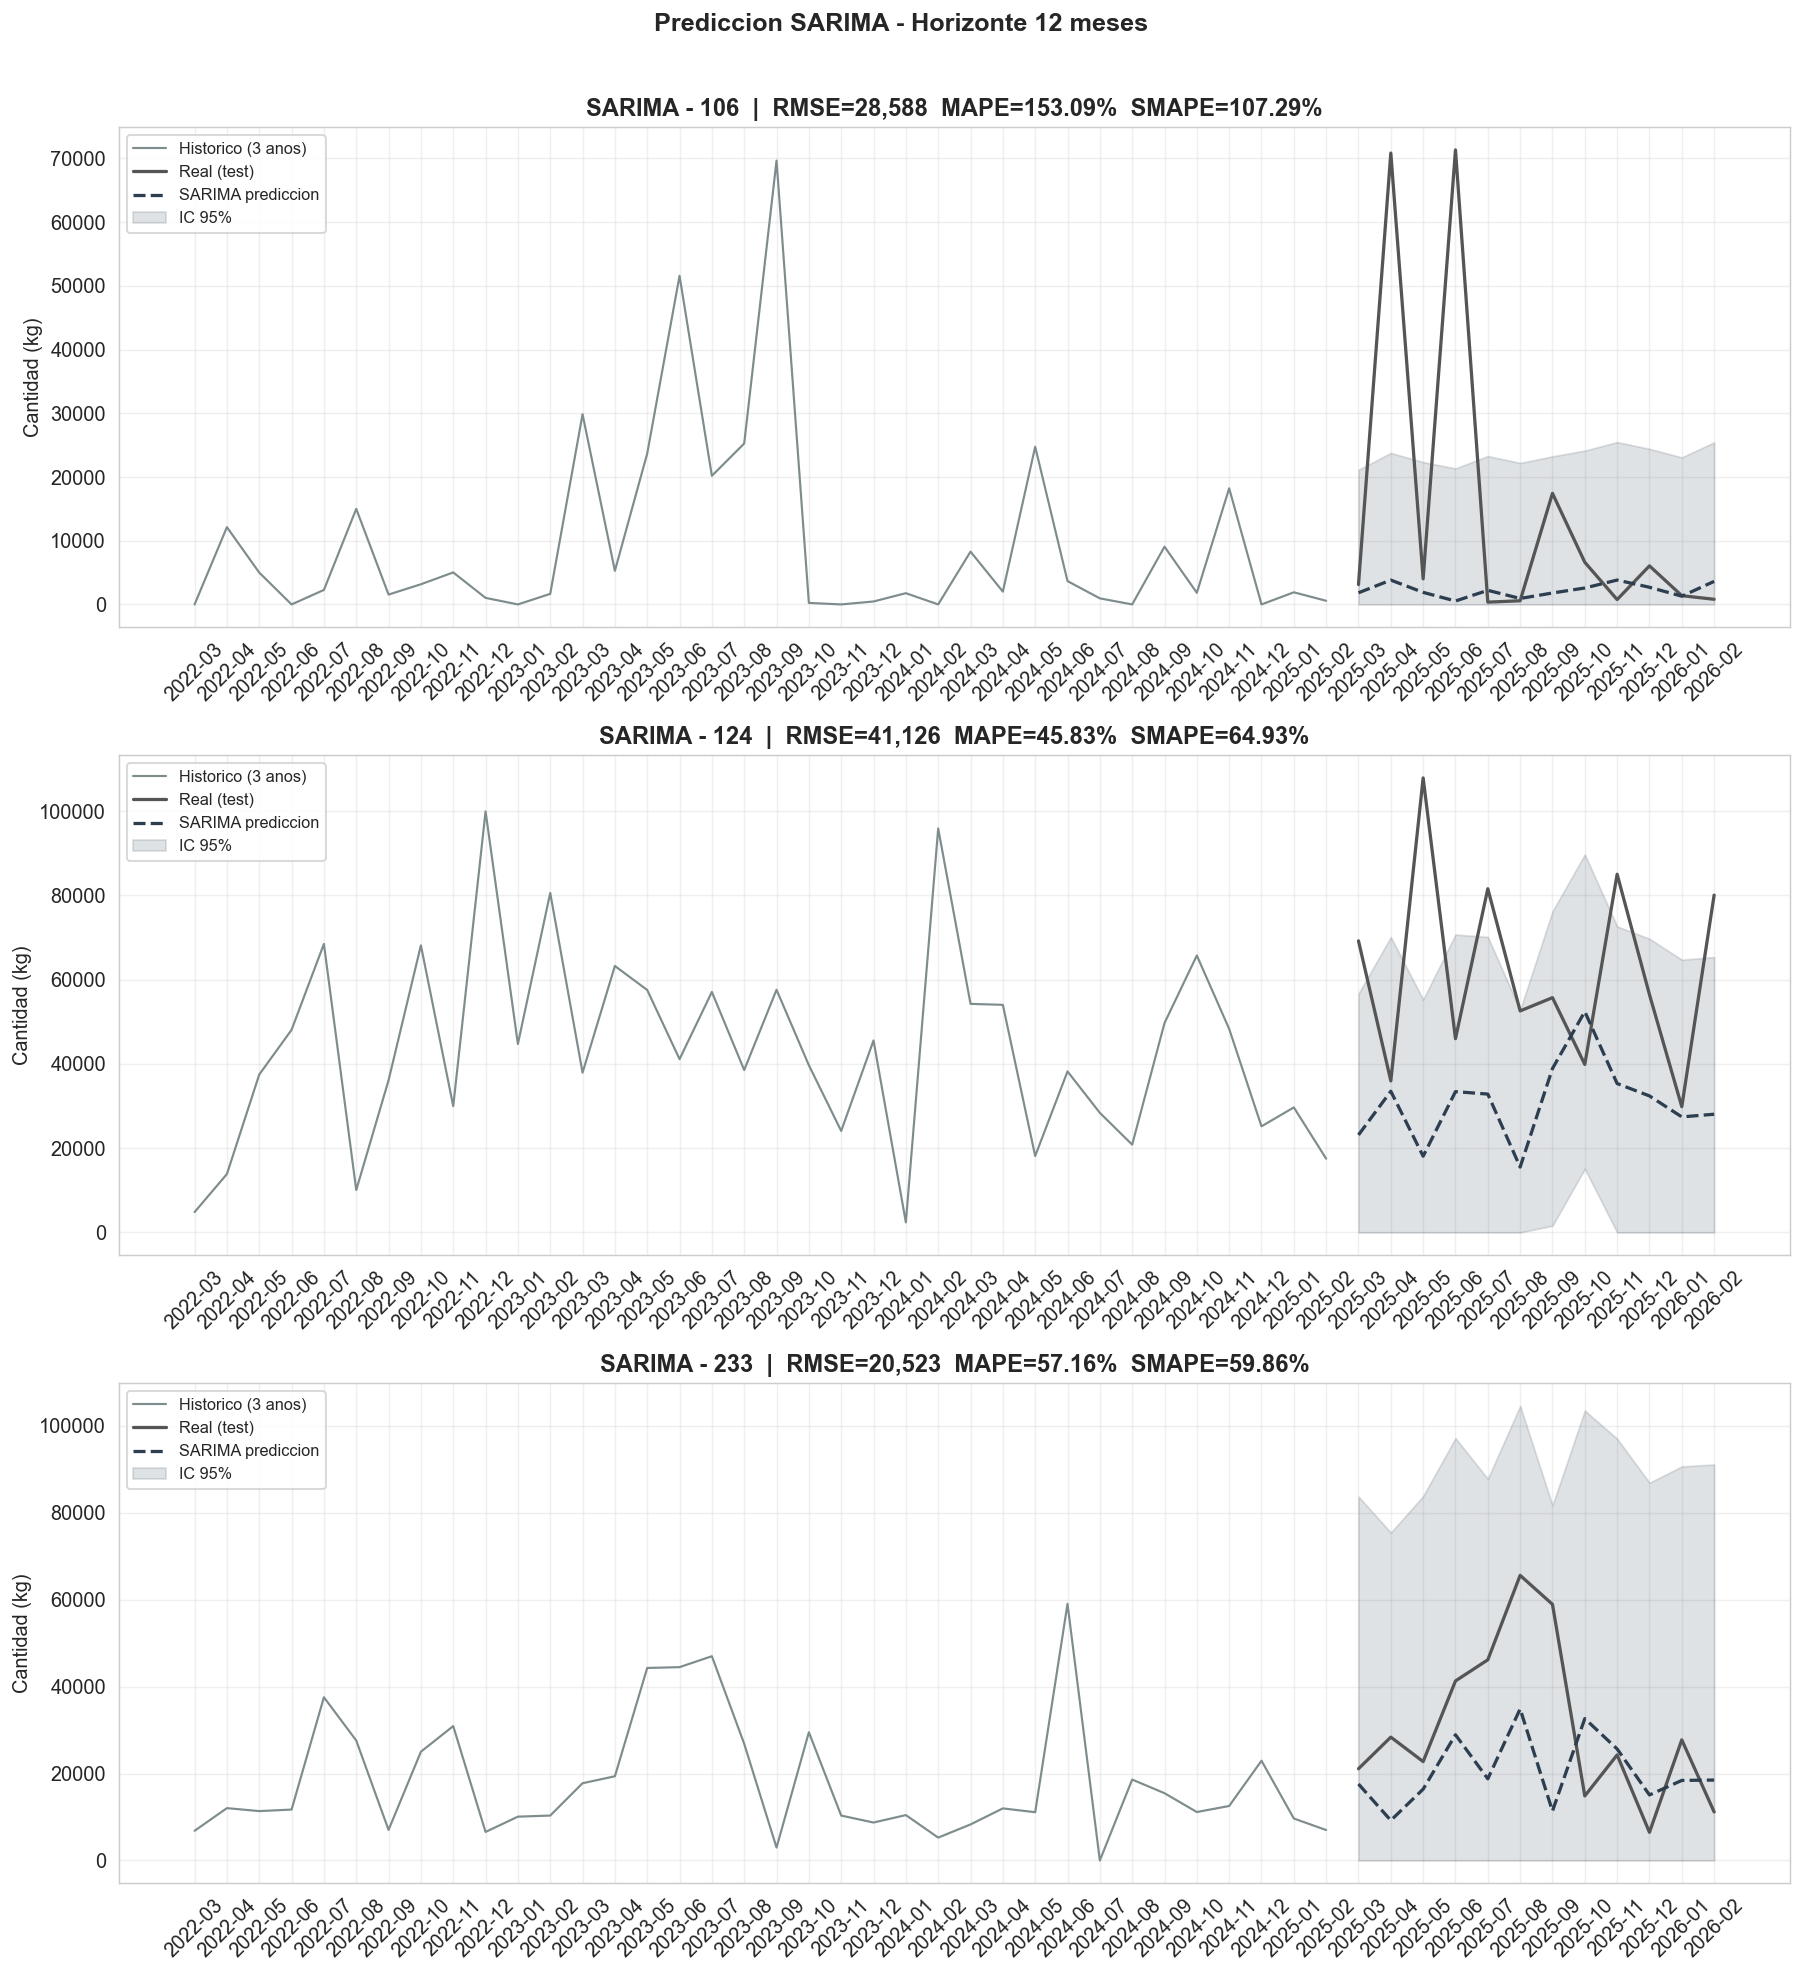

Figura guardada: figuras/04_prediccion_SARIMA.pdf


In [8]:
fig, axes = plt.subplots(len(FAMILIAS), 1,
                          figsize=(14, 5 * len(FAMILIAS)), sharex=False)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    color    = COLORES.get(familia, '#555')
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    pred     = predicciones_sarima[familia]
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    ax.plot(list(ctx_idx[:36]), ctx_train,
            color='#7f8c8d', lw=1.2, label='Historico (3 anos)')
    ax.plot(list(test_idx), pred['test'],
            color=color, lw=1.8, label='Real (test)')
    ax.plot(list(test_idx), pred['fc_mean'],
            color='#2c3e50', lw=1.8, ls='--', label='SARIMA prediccion')
    ax.fill_between(list(test_idx),
                    pred['fc_lower'], pred['fc_upper'],
                    alpha=0.15, color='#2c3e50',
                    label=f'IC {int((1-ALPHA)*100)}%')

    m = next(r for r in resultados_sarima if r['Familia'] == familia)
    ax.set_title(
        f'SARIMA - {familia}  |  RMSE={m["RMSE"]:,.0f}  '
        f'MAPE={m["MAPE_%"]}%  SMAPE={m["SMAPE_%"]}%',
        fontweight='bold'
    )
    ax.set_ylabel('Cantidad (kg)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Prediccion SARIMA - Horizonte 12 meses',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figuras/04_prediccion_SARIMA.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_prediccion_SARIMA.pdf')

## 3. Modelo Prophet

Prophet descompone la serie como:
y(t) = g(t) + s(t) + h(t) + error

- g(t): tendencia lineal por tramos con changepoints automaticos
- s(t): estacionalidad via series de Fourier
- h(t): efectos de eventos especiales

Ventaja frente a SARIMA: maneja changepoints automaticamente
y es robusto a valores faltantes.

In [9]:
resultados_prophet   = []
predicciones_prophet = {}
modelos_prophet      = {}

for familia in FAMILIAS:
    serie = ventas_mensual[familia]

    df_p = pd.DataFrame({
        'ds': fechas_dt,
        'y' : ventas_mensual_wins[familia].values   # ← wins en lugar de serie.values
    })

    df_train = df_p.iloc[:-H]
    df_test  = df_p.iloc[-H:]

    m = Prophet(
        seasonality_mode        = 'additive',
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 10.0,
        interval_width          = 1 - ALPHA
    )
    m.add_seasonality(name='mensual', period=30.5, fourier_order=6)
    m.fit(df_train)
    modelos_prophet[familia] = m

    future   = m.make_future_dataframe(periods=H, freq='MS')
    forecast = m.predict(future)

    fc_mean  = np.clip(forecast['yhat'].values[-H:],       0, None)
    fc_lower = np.clip(forecast['yhat_lower'].values[-H:], 0, None)
    fc_upper = forecast['yhat_upper'].values[-H:]
    test_vals = df_test['y'].values

    metricas = calcular_metricas(test_vals, fc_mean, 'Prophet', familia)
    resultados_prophet.append(metricas)
    predicciones_prophet[familia] = {
        'test'         : test_vals,
        'fc_mean'      : fc_mean,
        'fc_lower'     : fc_lower,
        'fc_upper'     : fc_upper,
        'forecast_full': forecast,
    }

    print(f'[{familia}]  RMSE={metricas["RMSE"]:>10.2f}  '
          f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
          f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nProphet completado.')

09:50:10 - cmdstanpy - INFO - Chain [1] start processing
09:50:10 - cmdstanpy - INFO - Chain [1] done processing
09:50:10 - cmdstanpy - INFO - Chain [1] start processing
09:50:10 - cmdstanpy - INFO - Chain [1] done processing


[106]  RMSE=  11076.72  MAPE=972.54%  SMAPE=117.10%


09:50:11 - cmdstanpy - INFO - Chain [1] start processing
09:50:11 - cmdstanpy - INFO - Chain [1] done processing


[124]  RMSE=  24109.79  MAPE= 33.40%  SMAPE= 41.87%
[233]  RMSE=  27388.05  MAPE= 55.02%  SMAPE= 85.15%

Prophet completado.


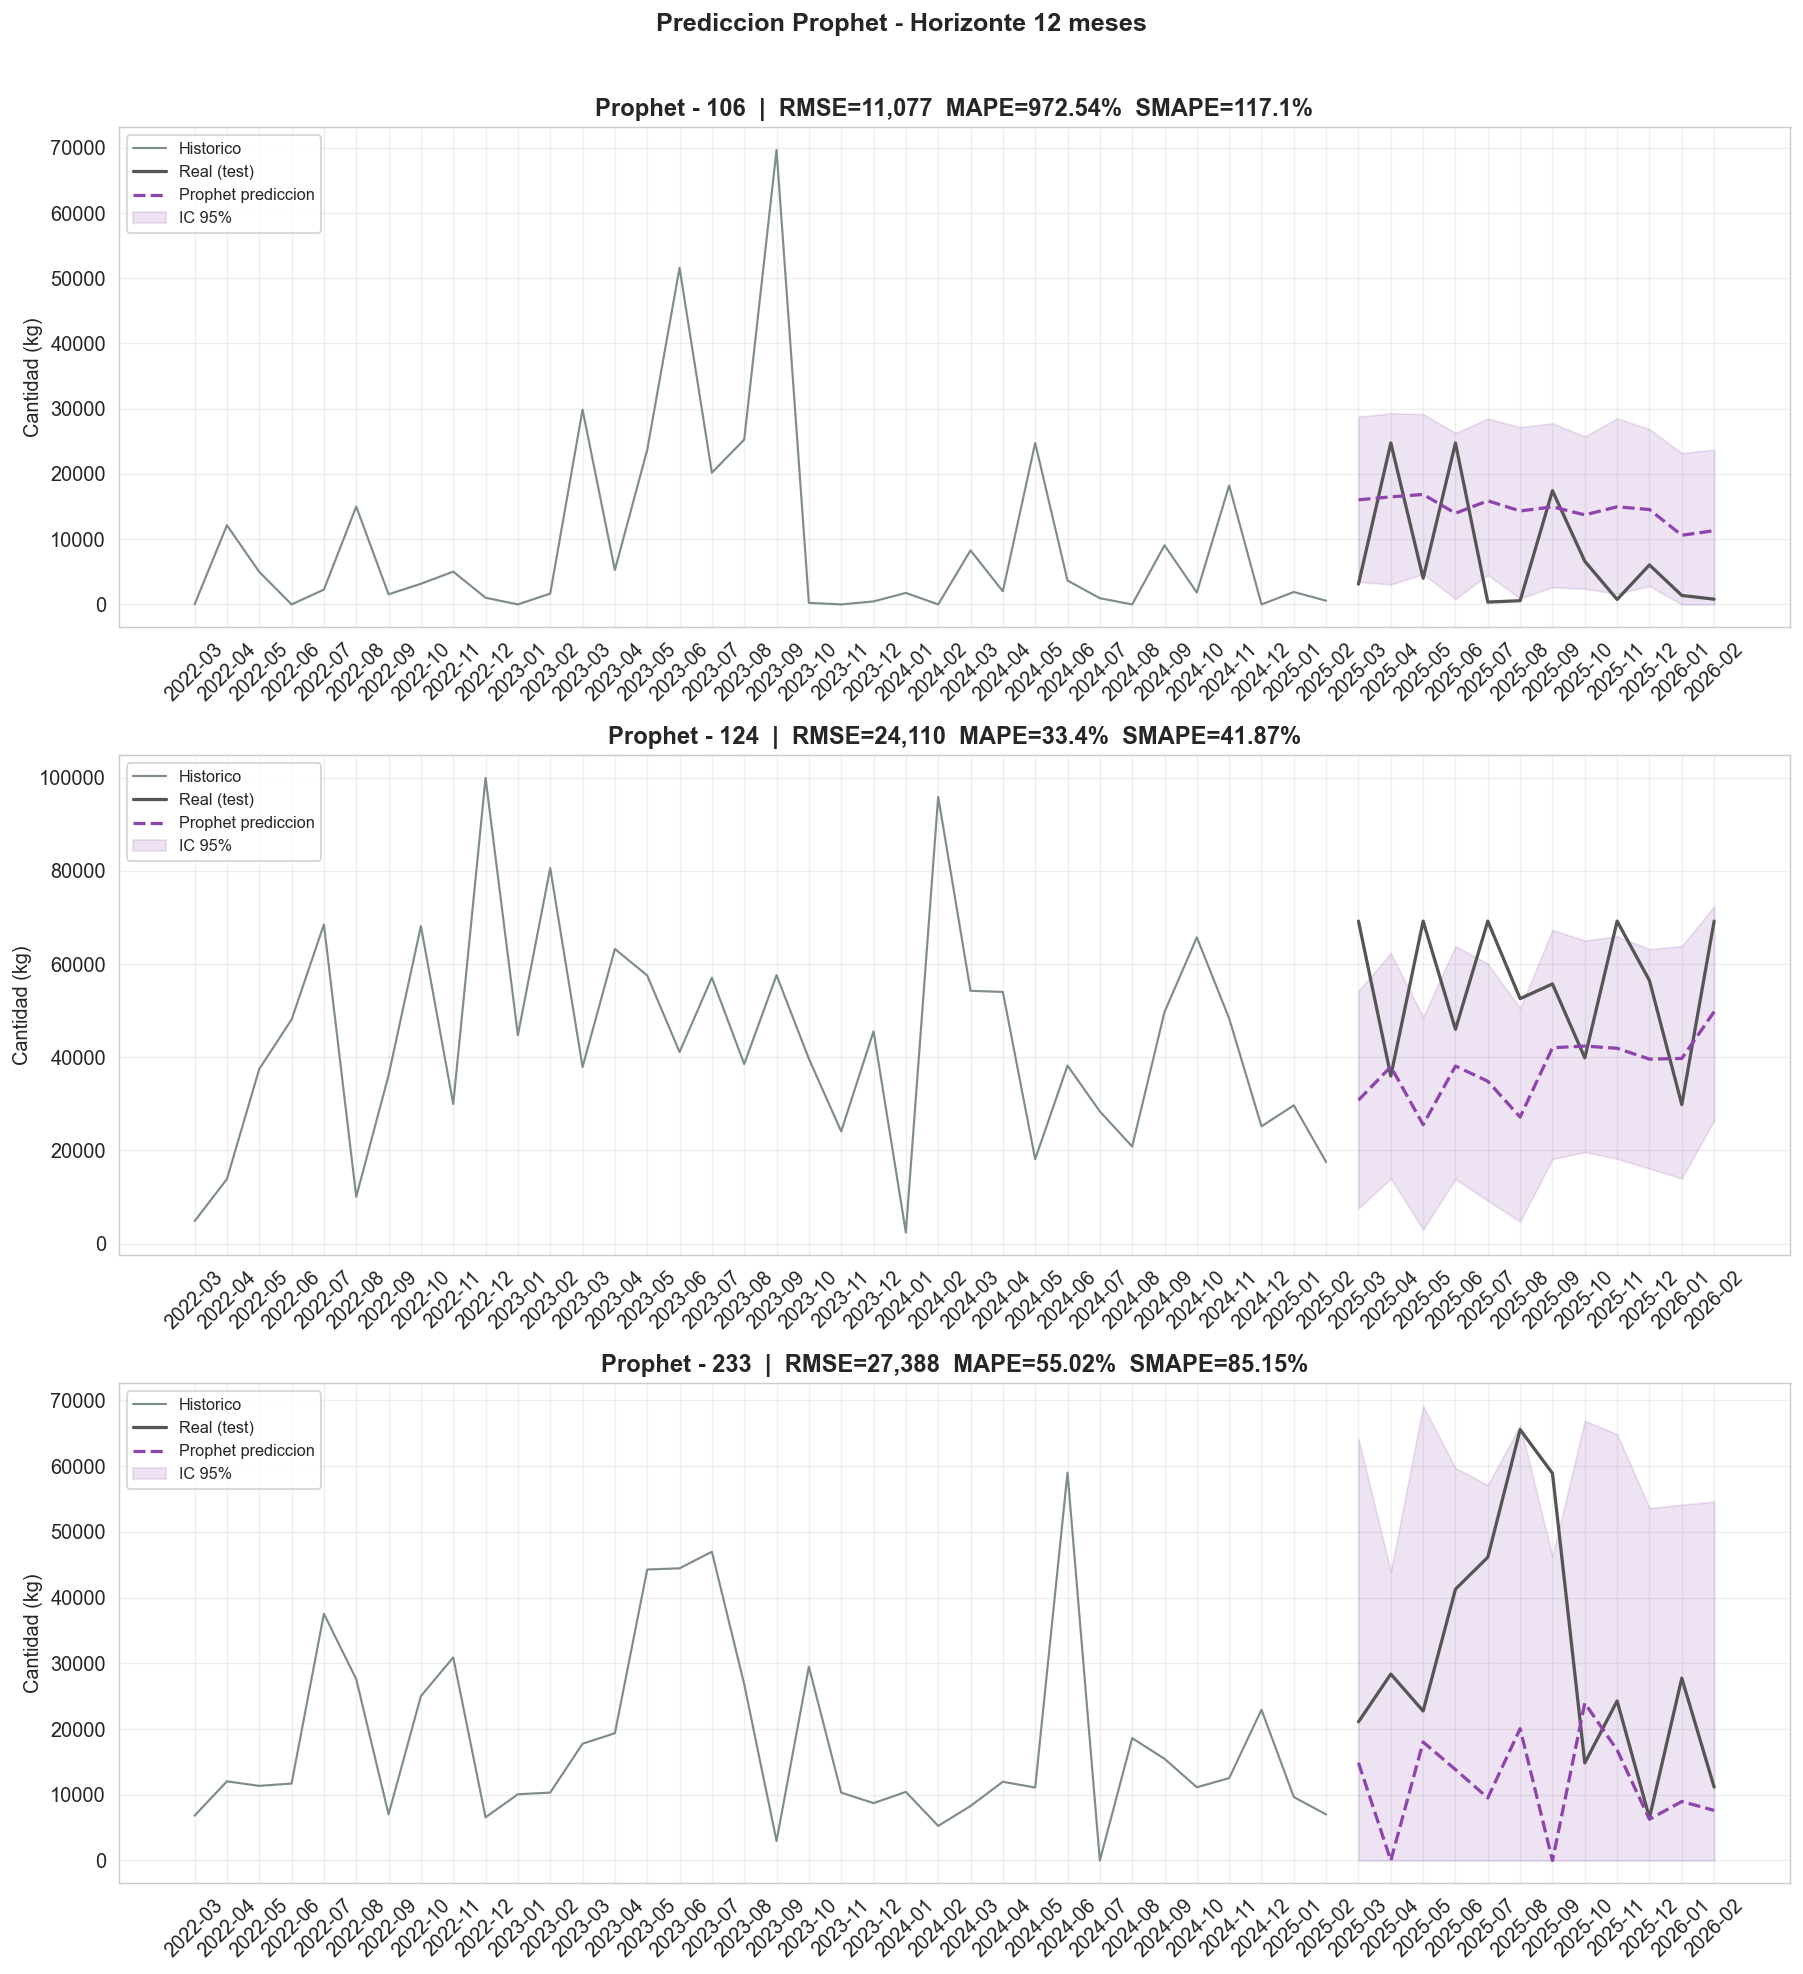

Figura guardada: figuras/04_prediccion_Prophet.pdf


In [10]:
fig, axes = plt.subplots(len(FAMILIAS), 1,
                          figsize=(14, 5 * len(FAMILIAS)), sharex=False)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    color    = COLORES.get(familia, '#555')
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    pred     = predicciones_prophet[familia]
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    ax.plot(list(ctx_idx[:36]), ctx_train,
            color='#7f8c8d', lw=1.2, label='Historico')
    ax.plot(list(test_idx), pred['test'],
            color=color, lw=1.8, label='Real (test)')
    ax.plot(list(test_idx), pred['fc_mean'],
            color='#8e44ad', lw=1.8, ls='--', label='Prophet prediccion')
    ax.fill_between(list(test_idx),
                    pred['fc_lower'], pred['fc_upper'],
                    alpha=0.15, color='#8e44ad',
                    label=f'IC {int((1-ALPHA)*100)}%')

    m_res = next(r for r in resultados_prophet if r['Familia'] == familia)
    ax.set_title(
        f'Prophet - {familia}  |  RMSE={m_res["RMSE"]:,.0f}  '
        f'MAPE={m_res["MAPE_%"]}%  SMAPE={m_res["SMAPE_%"]}%',
        fontweight='bold'
    )
    ax.set_ylabel('Cantidad (kg)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Prediccion Prophet - Horizonte 12 meses',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figuras/04_prediccion_Prophet.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_prediccion_Prophet.pdf')

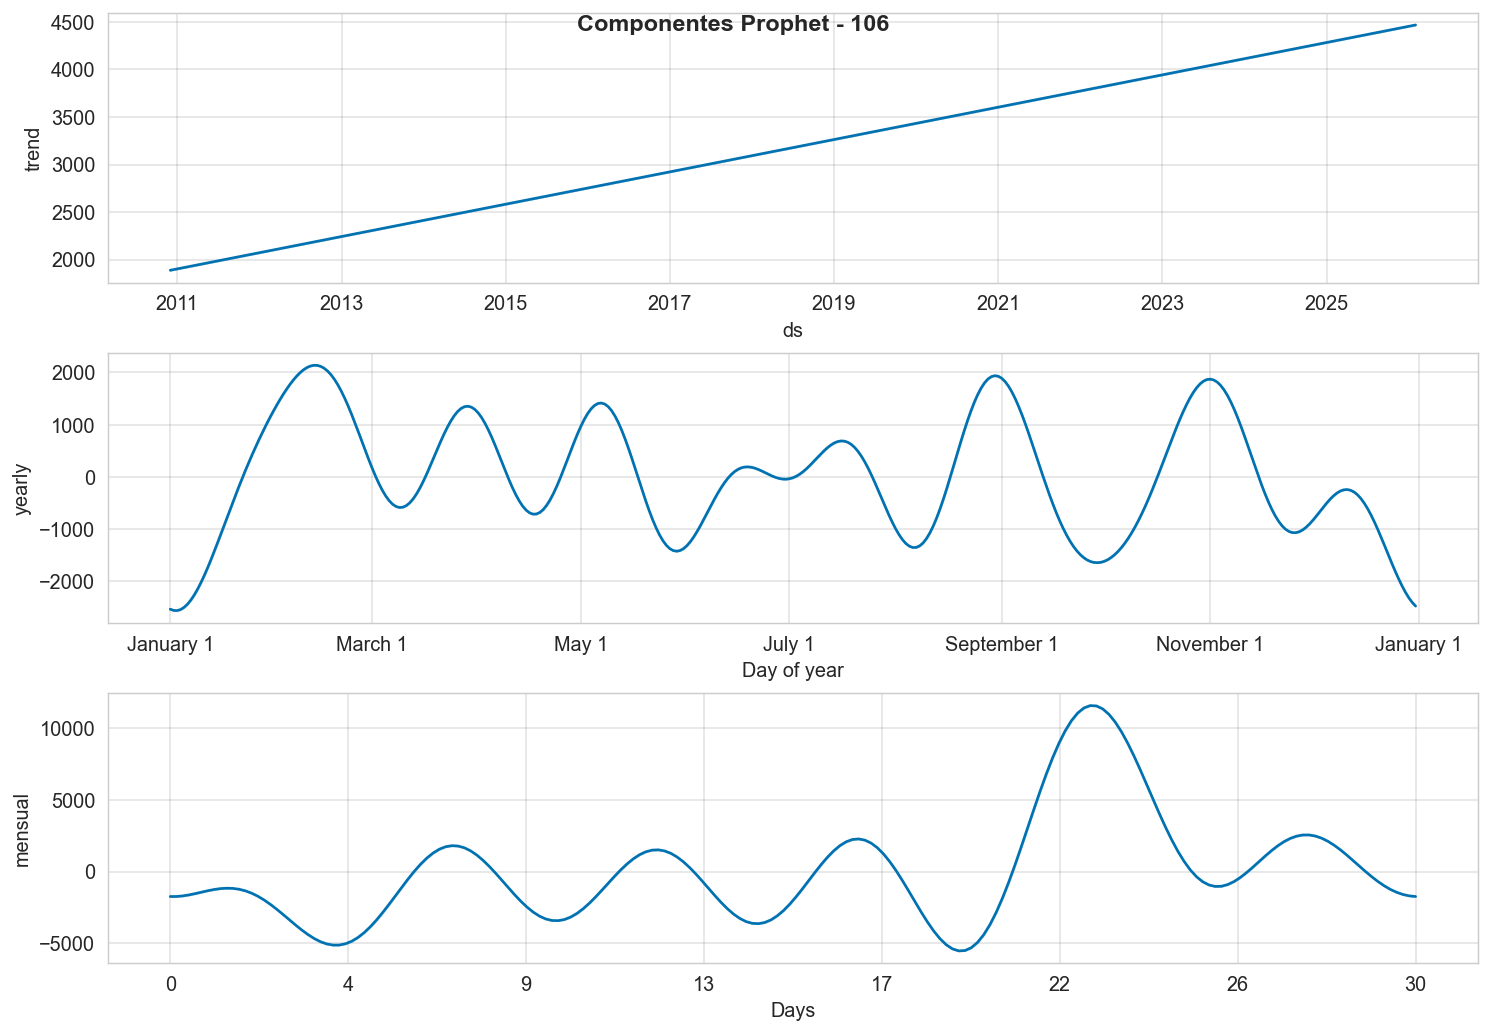

Figura guardada: ../figuras/04_componentes_Prophet_106.pdf


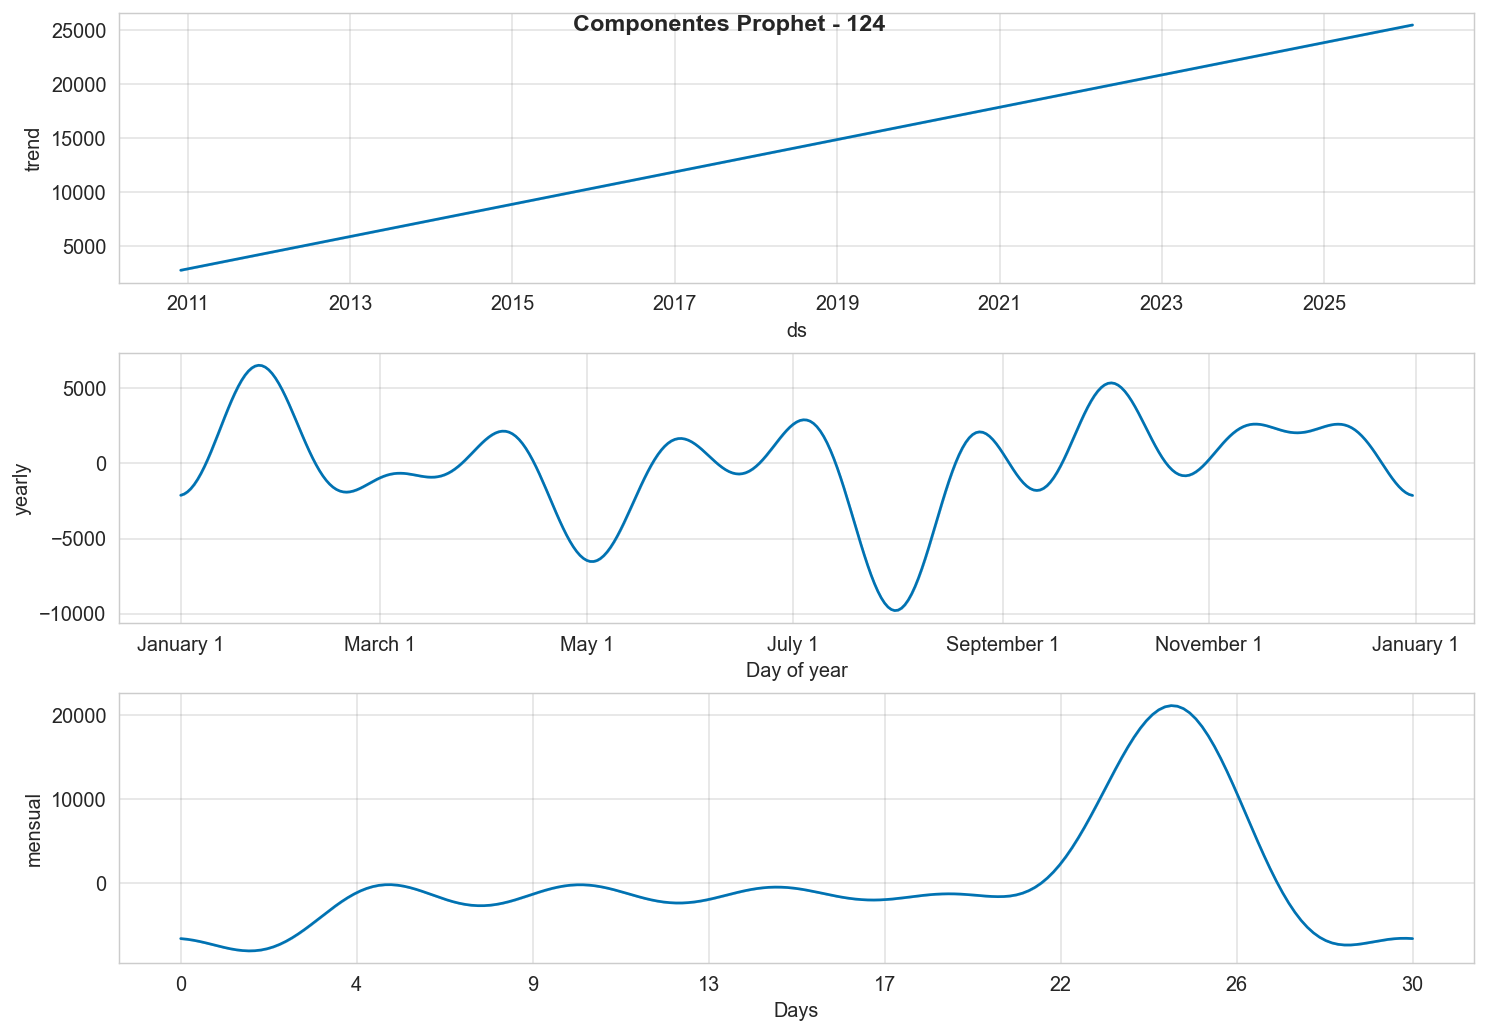

Figura guardada: ../figuras/04_componentes_Prophet_124.pdf


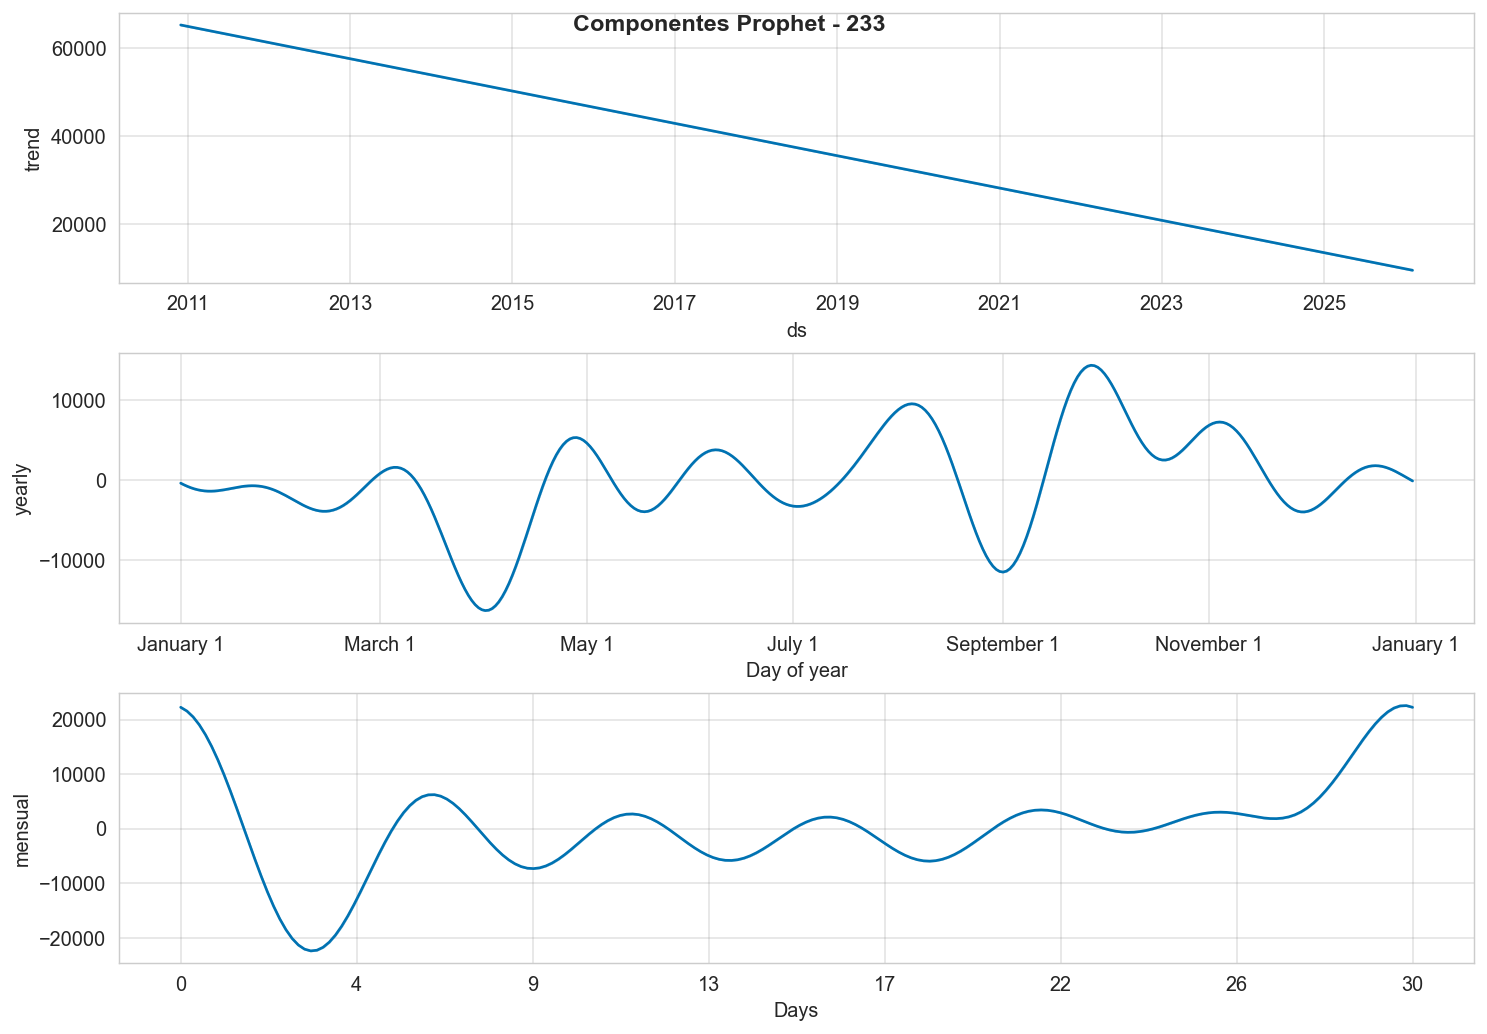

Figura guardada: ../figuras/04_componentes_Prophet_233.pdf


In [11]:
for familia in FAMILIAS:
    m        = modelos_prophet[familia]
    forecast = predicciones_prophet[familia]['forecast_full']
    fig      = m.plot_components(forecast)
    fig.set_size_inches(12, 8)
    fig.suptitle(f'Componentes Prophet - {familia}',
                 fontsize=13, fontweight='bold')
    fname = f'../figuras/04_componentes_Prophet_{familia}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

## 4. Comparativa SARIMA vs Prophet

In [12]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_metricas = pd.DataFrame(resultados_sarima + resultados_prophet)
df_pivot    = df_metricas.pivot_table(
    index='Familia', columns='Modelo',
    values=['RMSE', 'MAE', 'MAPE_%', 'SMAPE_%']
).round(2)

print('Tabla comparativa:')
print(df_pivot.to_string())
df_metricas.to_csv('../data/processed/04_metricas_SARIMA_Prophet.csv', index=False)
print('\nCSV guardado.')

Tabla comparativa:
              MAE            MAPE_%              RMSE           SMAPE_%        
Modelo    Prophet    SARIMA Prophet  SARIMA   Prophet    SARIMA Prophet  SARIMA
Familia                                                                        
106      10507.47  14373.90  972.54  153.09  11076.72  28588.10  117.10  107.29
124      20124.37  32852.70   33.40   45.83  24109.79  41125.91   41.87   64.93
233      20570.75  15946.08   55.02   57.16  27388.05  20523.34   85.15   59.86

CSV guardado.


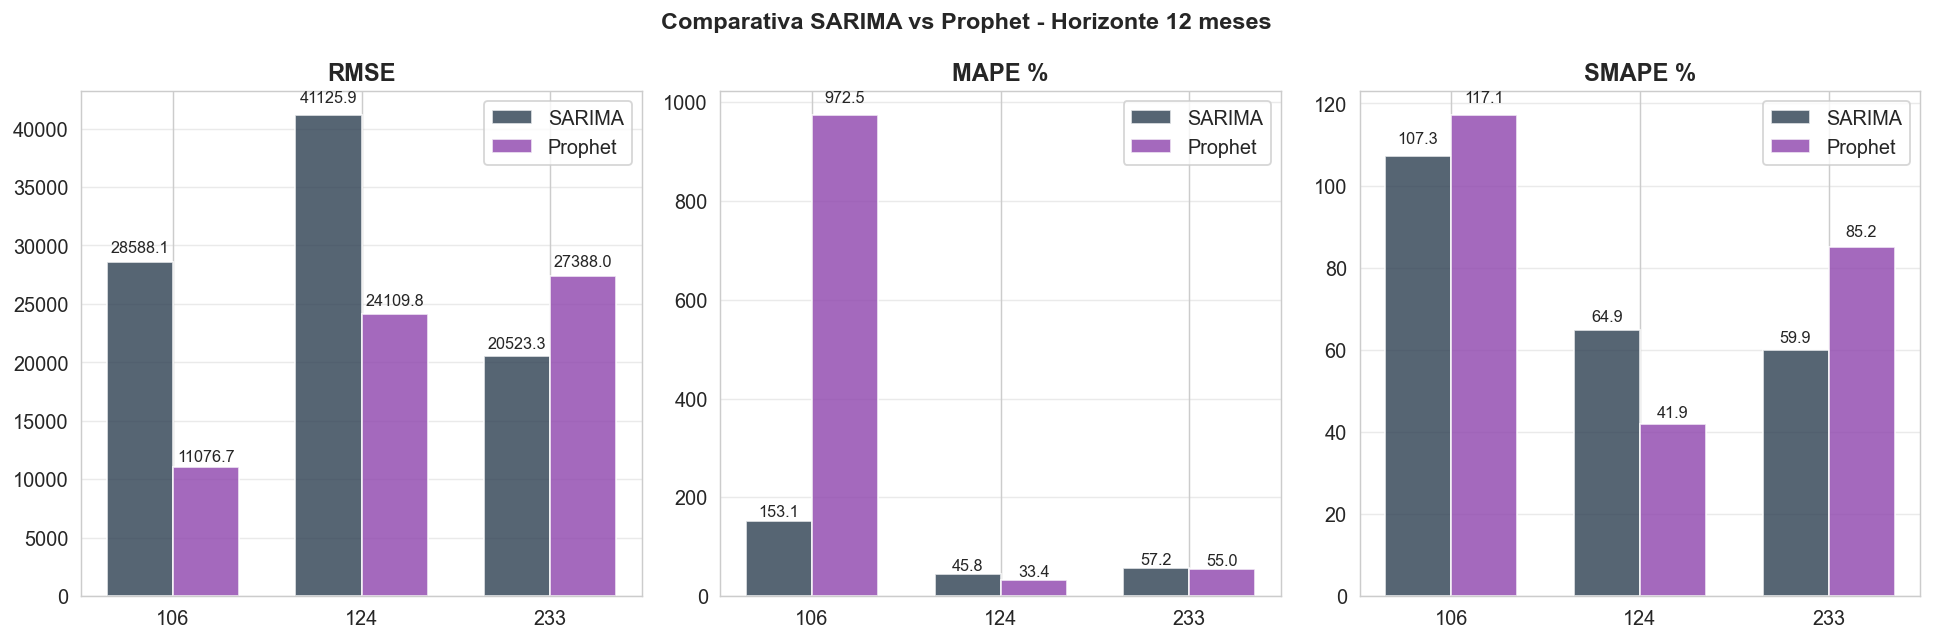

In [13]:
# ── Gráfico de barras comparativo ─────────────────────────────────────────────
metrics_plot = ['RMSE', 'MAPE_%', 'SMAPE_%']
fig, axes    = plt.subplots(1, 3, figsize=(15, 5))
familias_ord = sorted(FAMILIAS)
x, width     = np.arange(len(familias_ord)), 0.35

for ax, metric in zip(axes, metrics_plot):
    sub    = df_metricas[df_metricas['Familia'].isin(familias_ord)]
    vals_s = [sub[(sub.Familia == f) & (sub.Modelo == 'SARIMA')][metric].values[0]  for f in familias_ord]
    vals_p = [sub[(sub.Familia == f) & (sub.Modelo == 'Prophet')][metric].values[0] for f in familias_ord]

    bars1 = ax.bar(x - width/2, vals_s, width, label='SARIMA',  color='#2c3e50', alpha=0.8)
    bars2 = ax.bar(x + width/2, vals_p, width, label='Prophet', color='#8e44ad', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(familias_ord)
    ax.set_title(metric.replace('_', ' '), fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativa SARIMA vs Prophet - Horizonte 12 meses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/04_comparativa_metricas.pdf', bbox_inches='tight')
plt.show()

## 5. Exportacion de predicciones para optimizacion de stock

In [14]:
# ── Exportar predicciones ─────────────────────────────────────────────────────
fechas_test = ventas_mensual.index[-H:].to_timestamp()
rows = []
for familia in FAMILIAS:
    s_pred = predicciones_sarima[familia]
    p_pred = predicciones_prophet[familia]
    for i, fecha in enumerate(fechas_test):
        rows.append({
            'FECHA'        : fecha, 'FAMILIA'      : familia,
            'REAL'         : s_pred['test'][i],
            'SARIMA_PRED'  : s_pred['fc_mean'][i],
            'SARIMA_LOWER' : s_pred['fc_lower'][i],
            'SARIMA_UPPER' : s_pred['fc_upper'][i],
            'PROPHET_PRED' : p_pred['fc_mean'][i],
            'PROPHET_LOWER': p_pred['fc_lower'][i],
            'PROPHET_UPPER': p_pred['fc_upper'][i],
        })

df_pred = pd.DataFrame(rows)
df_pred.to_csv('../data/processed/04_predicciones_test.csv', index=False)
print('Predicciones exportadas.')

Predicciones exportadas.


In [15]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN NOTEBOOK 04')
print('=' * 65)
for familia in FAMILIAS:
    ords = ordenes_sarima[familia]
    m_s  = next(r for r in resultados_sarima  if r['Familia'] == familia)
    m_p  = next(r for r in resultados_prophet if r['Familia'] == familia)
    mejor_rmse = 'SARIMA' if m_s['RMSE']    < m_p['RMSE']    else 'Prophet'
    mejor_smape= 'SARIMA' if m_s['SMAPE_%'] < m_p['SMAPE_%'] else 'Prophet'
    print(f'\n[{familia}]')
    print(f'  SARIMA{ords["order"]} x {ords["seasonal_order"]}  AIC={ords["aic"]}')
    print(f'    RMSE={m_s["RMSE"]:>10,.2f}  MAPE={m_s["MAPE_%"]:>6.2f}%  SMAPE={m_s["SMAPE_%"]:>6.2f}%')
    print(f'  Prophet:')
    print(f'    RMSE={m_p["RMSE"]:>10,.2f}  MAPE={m_p["MAPE_%"]:>6.2f}%  SMAPE={m_p["SMAPE_%"]:>6.2f}%')
    print(f'  -> Mejor RMSE: {mejor_rmse}  |  Mejor SMAPE: {mejor_smape}')

print('\n' + '=' * 65)
print('Proximo: Notebook 05 - XGBoost')

RESUMEN NOTEBOOK 04

[106]
  SARIMA(1, 0, 1) x (2, 1, 1, 12)  AIC=2883.16
    RMSE= 28,588.10  MAPE=153.09%  SMAPE=107.29%
  Prophet:
    RMSE= 11,076.72  MAPE=972.54%  SMAPE=117.10%
  -> Mejor RMSE: Prophet  |  Mejor SMAPE: SARIMA

[124]
  SARIMA(1, 0, 0) x (0, 1, 2, 12)  AIC=3076.01
    RMSE= 41,125.91  MAPE= 45.83%  SMAPE= 64.93%
  Prophet:
    RMSE= 24,109.79  MAPE= 33.40%  SMAPE= 41.87%
  -> Mejor RMSE: Prophet  |  Mejor SMAPE: Prophet

[233]
  SARIMA(2, 0, 1) x (0, 1, 1, 12)  AIC=3255.22
    RMSE= 20,523.34  MAPE= 57.16%  SMAPE= 59.86%
  Prophet:
    RMSE= 27,388.05  MAPE= 55.02%  SMAPE= 85.15%
  -> Mejor RMSE: SARIMA  |  Mejor SMAPE: SARIMA

Proximo: Notebook 05 - XGBoost
